In [1]:
# ============================================================
# Cell 1 — Install / Verify Dependencies
# ============================================================
!pip install torch torchvision torchaudio --quiet
!pip install numpy pandas scikit-learn matplotlib --quiet
print('✅ All dependencies ready.')

✅ All dependencies ready.


In [2]:
# ============================================================
# Cell 3 — Imports
# ============================================================
import os, math, time, random, warnings, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128


In [3]:
# ============================================================
# Cell 4 — Configuration  (STRICTLY FIXED — DO NOT MODIFY)
# ============================================================

DATA_PATH    = '/content/ceemdan_components.csv'
OUTPUT_CSV   = '/content/experiment_results_CeemdanLSTM.csv'
OUTPUT_TXT   = '/content/experiment_summary_CEEMDANLSTM.txt'

# Components
IMF_COLS     = ['IMF1','IMF2','IMF3','IMF4','IMF5','IMF6','IMF7','IMF8']
RESIDUAL_COL = 'Residual'
TARGET_COL   = 'Close'
# IMF8 gets special first-difference treatment (non-stationary trend)
MINMAX_COMPS = ['IMF1','IMF2','IMF3','IMF4','IMF5','IMF6','IMF7','Residual']
ALL_COMPONENTS = IMF_COLS + [RESIDUAL_COL]   # 9 total

# LSTM hyperparameters — FIXED as per specification
LOOK_BACK    = 20
PRED_LEN     = 1
NUM_LAYERS   = 4
HIDDEN_SIZE  = 4
DROPOUT      = 0.1
EPOCHS       = 100
BATCH_SIZE   = 32
LR           = 0.001

# Experiment settings
N_EXPERIMENTS      = 50          # seeds 1 → 50
ROLLING_VOL_WINDOW = 30
MULTISTEP_HORIZONS = [5, 21]

print('Config loaded.')
print(f'  MinMaxScaler comps : {MINMAX_COMPS}')
print(f'  IMF8 : FirstDiff + StandardScaler + CumSum reconstruction')
print(f'  LSTM : hidden={HIDDEN_SIZE} | layers={NUM_LAYERS}'
      f' | dropout={DROPOUT} | epochs={EPOCHS} | lr={LR}')

Config loaded.
  MinMaxScaler comps : ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'Residual']
  IMF8 : FirstDiff + StandardScaler + CumSum reconstruction
  LSTM : hidden=4 | layers=4 | dropout=0.1 | epochs=100 | lr=0.001


In [4]:
# ============================================================
# Cell 5 — Seed Control
# ============================================================
def set_seed(seed: int):
    """Fully deterministic seeding per specification."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print('set_seed() defined  →  seeds 1–50.')

set_seed() defined  →  seeds 1–50.


In [5]:
# ============================================================
# Cell 6 — Load Data & Chronological Split
# ============================================================
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Strict chronological split — no shuffling, no leakage
train_mask    = df['Date'].dt.year <= 2022
test_mask     = df['Date'].dt.year >= 2023
df_train_full = df[train_mask].reset_index(drop=True)
df_test       = df[test_mask].reset_index(drop=True)

# Validation = last 10% of training period (time-ordered)
val_size  = int(len(df_train_full) * 0.10)
df_train  = df_train_full.iloc[:-val_size].reset_index(drop=True)
df_val    = df_train_full.iloc[-val_size:].reset_index(drop=True)

print(f'Dataset : {df.shape}  ({df.Date.min().date()} → {df.Date.max().date()})')
print(f'Train   : {len(df_train):>5}  ({df_train.Date.min().date()} → {df_train.Date.max().date()})')
print(f'Val     : {len(df_val):>5}  ({df_val.Date.min().date()} → {df_val.Date.max().date()})')
print(f'Test    : {len(df_test):>5}  ({df_test.Date.min().date()} → {df_test.Date.max().date()})')

# Verify IMF8 distribution to confirm extrapolation risk
print(f'\nIMF8 range: train max={df_train["IMF8"].max():.0f}  '
      f'test max={df_test["IMF8"].max():.0f}  ← needs first-diff fix')

Dataset : (2599, 11)  (2015-01-09 → 2025-07-25)
Train   :  1770  (2015-01-09 → 2022-03-16)
Val     :   196  (2022-03-17 → 2022-12-30)
Test    :   633  (2023-01-02 → 2025-07-25)

IMF8 range: train max=16783  test max=23158  ← needs first-diff fix


In [6]:
# ============================================================
# Cell 7 — Windowing Utility & Dataset Class
# ============================================================
def create_windows(series: np.ndarray, look_back: int):
    """
    Sliding-window supervised learning.
    X[i] = series[i:i+look_back]  shape (look_back, 1)
    y[i] = series[i+look_back]    scalar
    No leakage: predicts t from [t-look_back .. t-1].
    """
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i: i + look_back])
        y.append(series[i + look_back])
    X = np.array(X, dtype=np.float32)[..., np.newaxis]  # (N, look_back, 1)
    y = np.array(y, dtype=np.float32)                   # (N,)
    return X, y


class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


print(f'create_windows() defined — input shape (batch, {LOOK_BACK}, 1)')

create_windows() defined — input shape (batch, 20, 1)


In [7]:
# ============================================================
# Cell 8 — LSTM Model Definition  (FIXED hyperparameters)
# ============================================================
class LSTMModel(nn.Module):
    """
    Stacked LSTM for single-step forecasting.
    hidden=4 | layers=4 | dropout=0.1
    Input : (B, look_back, 1)   Output : (B,)
    """
    def __init__(self,
                 input_size  = 1,
                 hidden_size = HIDDEN_SIZE,
                 num_layers  = NUM_LAYERS,
                 dropout     = DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)           # (B, look_back, hidden)
        return self.fc(out[:, -1, :]).squeeze(-1)  # (B,)


print(f'LSTMModel: hidden={HIDDEN_SIZE} | layers={NUM_LAYERS}'
      f' | dropout={DROPOUT}')

LSTMModel: hidden=4 | layers=4 | dropout=0.1


In [8]:
# ============================================================
# Cell 9 — Metrics Helper
# ============================================================
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """MAE, RMSE, MAPE, R² on original-scale arrays."""
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    mae  = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mask = np.abs(y_true) > 1e-8
    mape = float(np.mean(np.abs(
        (y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    r2   = float(r2_score(y_true, y_pred))
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


print('compute_metrics() → MAE | RMSE | MAPE | R²')

compute_metrics() → MAE | RMSE | MAPE | R²


In [9]:
# ============================================================
# Cell 10 — Generic LSTM Training Loop
# ============================================================
def _train_lstm(train_sc: np.ndarray,
                val_sc  : np.ndarray,
                test_sc : np.ndarray,
                patience: int = 10) -> tuple:
    """
    Train a fresh LSTMModel on pre-scaled sequences.
    Returns (trained_model, test_predictions_scaled).
    """
    X_tr, y_tr = create_windows(train_sc, LOOK_BACK)
    X_vl, y_vl = create_windows(
        np.concatenate([train_sc[-LOOK_BACK:], val_sc]), LOOK_BACK)
    X_te, y_te = create_windows(
        np.concatenate([val_sc[-LOOK_BACK:], test_sc]), LOOK_BACK)

    pin = (DEVICE.type == 'cuda')
    tr_dl = DataLoader(TSDataset(X_tr, y_tr), BATCH_SIZE,
                       shuffle=False, pin_memory=pin)
    vl_dl = DataLoader(TSDataset(X_vl, y_vl), BATCH_SIZE, shuffle=False)
    te_dl = DataLoader(TSDataset(X_te, y_te), BATCH_SIZE, shuffle=False)

    model  = LSTMModel().to(DEVICE)
    opt    = Adam(model.parameters(), lr=LR)
    crit   = nn.MSELoss()
    best_v = float('inf');  best_w = None;  no_imp = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        vl = []
        with torch.no_grad():
            for Xb, yb in vl_dl:
                vl.append(crit(model(Xb.to(DEVICE)),
                               yb.to(DEVICE)).item())
        vl_loss = float(np.mean(vl))

        if vl_loss < best_v:
            best_v = vl_loss
            best_w = {k: v.clone().cpu()
                      for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_w.items()})
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in te_dl:
            preds.append(model(Xb.to(DEVICE)).cpu().numpy())

    return model, np.concatenate(preds)   # scaled predictions


print('_train_lstm() defined.')

_train_lstm() defined.


In [10]:
# ============================================================
# Cell 11 — Per-Component Training Functions
# ============================================================

# ── Standard MinMaxScaler path (IMF1-7 + Residual) ───────────
def train_minmax_component(comp, df_tr, df_vl, df_te, scalers):
    """
    Train LSTM with MinMaxScaler.
    Returns original-scale test predictions of shape (len(df_te),).
    """
    sc = scalers[comp]
    tr_sc = sc.transform(df_tr[[comp]].values).flatten().astype(np.float32)
    vl_sc = sc.transform(df_vl[[comp]].values).flatten().astype(np.float32)
    te_sc = sc.transform(df_te[[comp]].values).flatten().astype(np.float32)

    model, preds_sc = _train_lstm(tr_sc, vl_sc, te_sc)

    preds_orig = sc.inverse_transform(
        preds_sc.reshape(-1, 1)).flatten().astype(np.float64)
    return model, preds_orig


# ── IMF8 first-difference + StandardScaler path ──────────────
def train_imf8_firstdiff(df_tr, df_vl, df_te):
    """
    IMF8 is a non-stationary trend.  MinMaxScaler cannot extrapolate
    beyond the training range (test values >> training max).

    Fix:
      1. First-difference the raw series:  Δ[t] = IMF8[t] - IMF8[t-1]
      2. StandardScaler on differences (fit on train Δ only).
      3. Train LSTM on scaled differences.
      4. Inverse-transform predictions → Δ_hat.
      5. Reconstruct:  IMF8_hat[t] = IMF8_val[-1] + cumsum(Δ_hat).

    Returns original-scale test predictions of shape (len(df_te),).
    """
    tr_raw = df_tr['IMF8'].values.astype(np.float64)
    vl_raw = df_vl['IMF8'].values.astype(np.float64)
    te_raw = df_te['IMF8'].values.astype(np.float64)

    # First differences
    d_tr = np.diff(tr_raw)                                    # len-1
    d_vl = np.diff(np.concatenate([[tr_raw[-1]], vl_raw]))    # len val
    d_te = np.diff(np.concatenate([[vl_raw[-1]], te_raw]))    # len test

    # StandardScaler fitted on training differences only
    ss = StandardScaler()
    ss.fit(d_tr.reshape(-1, 1))
    d_tr_sc = ss.transform(d_tr.reshape(-1, 1)).flatten().astype(np.float32)
    d_vl_sc = ss.transform(d_vl.reshape(-1, 1)).flatten().astype(np.float32)
    d_te_sc = ss.transform(d_te.reshape(-1, 1)).flatten().astype(np.float32)

    model, delta_preds_sc = _train_lstm(d_tr_sc, d_vl_sc, d_te_sc)

    # Inverse-scale predicted differences
    delta_preds = ss.inverse_transform(
        delta_preds_sc.reshape(-1, 1)).flatten().astype(np.float64)

    # Reconstruct level from last known validation value
    anchor = float(vl_raw[-1])
    imf8_preds = anchor + np.cumsum(delta_preds)

    return model, ss, imf8_preds


print('Component training functions defined.')
print('  train_minmax_component() : IMF1-7 + Residual')
print('  train_imf8_firstdiff()   : IMF8 (non-stationary trend fix)')

Component training functions defined.
  train_minmax_component() : IMF1-7 + Residual
  train_imf8_firstdiff()   : IMF8 (non-stationary trend fix)


In [11]:
# ============================================================
# Cell 12 — Single-Experiment Runner
# ============================================================
def run_experiment(df_train, df_val, df_test,
                   seed: int) -> tuple:
    """
    Full CEEMDAN-LSTM pipeline for one seed:
      1. Set seed (deterministic).
      2. Fit MinMaxScalers on train only (8 components).
      3. Train 9 LSTMs (IMF8 via first-diff, rest via MinMax).
      4. Reconstruct: y_hat = sum of all 9 component predictions.
      5. Measure & return metrics + artefacts.
    """
    set_seed(seed)
    t0 = time.time()

    # Fit MinMaxScalers on train only
    scalers = {}
    for comp in MINMAX_COMPS:
        sc = MinMaxScaler(feature_range=(0, 1))
        sc.fit(df_train[[comp]].values)
        scalers[comp] = sc

    models     = {}
    comp_preds = {}

    # Train MinMax components
    for comp in MINMAX_COMPS:
        m, preds = train_minmax_component(
            comp, df_train, df_val, df_test, scalers)
        models[comp]     = m
        comp_preds[comp] = preds

    # Train IMF8 (first-diff pipeline)
    m8, ss8, preds8 = train_imf8_firstdiff(df_train, df_val, df_test)
    models['IMF8']     = m8
    comp_preds['IMF8'] = preds8

    t_elapsed = time.time() - t0

    # Reconstruct final prediction: y_hat = Σ all components
    # All predictions have length == len(df_test)
    n_test = len(df_test)
    y_hat  = np.zeros(n_test, dtype=np.float64)
    for comp in ALL_COMPONENTS:
        y_hat += comp_preds[comp][:n_test]

    y_true = df_test[TARGET_COL].values.astype(np.float64)
    # Window creation removes first LOOK_BACK rows from each component
    # → all comp_preds have length = len(df_test), aligned from
    #   test[LOOK_BACK:].  Align y_true accordingly.
    min_len = min(len(y_hat), len(y_true))
    y_hat_a = y_hat[:min_len]
    y_true_a = y_true[:min_len]

    metrics = compute_metrics(y_true_a, y_hat_a)
    metrics['training_time_sec'] = t_elapsed

    return metrics, models, scalers, comp_preds, y_true_a, y_hat_a


print('run_experiment() defined.')

run_experiment() defined.


In [12]:
# ============================================================
# Cell 13 — Run All 50 Experiments
# ============================================================
print(f'Device     : {DEVICE}')
print(f'Experiment : seed 1 → {N_EXPERIMENTS}')
print('='*65)

all_results   = []
_last_models  = _last_scalers = _last_comp_preds = None
_last_y_true  = _last_y_hat = None

for seed in range(1, N_EXPERIMENTS + 1):
    print(f'\n[{seed:02d}/{N_EXPERIMENTS}] seed={seed}', flush=True)

    m, models, scalers, cp, yt, yp = run_experiment(
        df_train, df_val, df_test, seed=seed)

    m['experiment'] = seed
    m['seed']       = seed
    all_results.append(m)

    print(f'  MAE={m["MAE"]:.2f}  RMSE={m["RMSE"]:.2f}  '
          f'MAPE={m["MAPE"]:.4f}%  R²={m["R2"]:.4f}  '
          f'time={m["training_time_sec"]:.1f}s', flush=True)

    _last_models  = models
    _last_scalers = scalers
    _last_comp_preds = cp
    _last_y_true  = yt
    _last_y_hat   = yp

print('\n✅ All 50 experiments complete.')

Device     : cuda
Experiment : seed 1 → 50

[01/50] seed=1
  MAE=651.97  RMSE=829.87  MAPE=3.0759%  R²=0.8979  time=140.5s

[02/50] seed=2
  MAE=358.11  RMSE=440.54  MAPE=1.6860%  R²=0.9712  time=101.7s

[03/50] seed=3
  MAE=1441.64  RMSE=1724.35  MAPE=6.3692%  R²=0.5590  time=69.9s

[04/50] seed=4
  MAE=1384.46  RMSE=1629.78  MAPE=6.0780%  R²=0.6061  time=82.5s

[05/50] seed=5
  MAE=315.78  RMSE=411.25  MAPE=1.5698%  R²=0.9749  time=129.3s

[06/50] seed=6
  MAE=1244.65  RMSE=1466.67  MAPE=5.4521%  R²=0.6810  time=106.8s

[07/50] seed=7
  MAE=314.78  RMSE=390.80  MAPE=1.4857%  R²=0.9774  time=109.7s

[08/50] seed=8
  MAE=305.59  RMSE=365.88  MAPE=1.4517%  R²=0.9801  time=117.7s

[09/50] seed=9
  MAE=1204.22  RMSE=1358.24  MAPE=5.4365%  R²=0.7264  time=102.9s

[10/50] seed=10
  MAE=1586.04  RMSE=1917.18  MAPE=6.8344%  R²=0.4549  time=81.1s

[11/50] seed=11
  MAE=1153.36  RMSE=1273.13  MAPE=5.4523%  R²=0.7596  time=109.6s

[12/50] seed=12
  MAE=573.16  RMSE=675.52  MAPE=2.6703%  R²=0.932

In [13]:
# ============================================================
# Cell 14 — Save Per-Experiment CSV
# ============================================================
fields = ['experiment','seed','MAE','RMSE','MAPE','R2','training_time_sec']
with open(OUTPUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields, extrasaction='ignore')
    w.writeheader()
    w.writerows(all_results)

print(f'Per-experiment CSV → {OUTPUT_CSV}')
pd.read_csv(OUTPUT_CSV)

Per-experiment CSV → /content/experiment_results_CeemdanLSTM.csv


,experiment,seed,MAE,RMSE,MAPE,R2,training_time_sec
0,1,1,651.970044,829.874044,3.075875,0.897862,140.473146
1,2,2,358.114967,440.540704,1.686018,0.971217,101.666445
2,3,3,1441.635246,1724.348169,6.369184,0.559027,69.889539
3,4,4,1384.464860,1629.776157,6.077987,0.606071,82.469872
4,5,5,315.783662,411.250575,1.569800,0.974917,129.258160
5,6,6,1244.650981,1466.665151,5.452070,0.680976,106.761046
6,7,7,314.779254,390.795005,1.485744,0.977350,109.707428
7,8,8,305.591652,365.884247,1.451734,0.980146,117.722585
8,9,9,1204.224096,1358.237740,5.436547,0.726402,102.898504
9,10,10,1586.039134,1917.183124,6.834368,0.454884,81.137130


In [14]:
# ============================================================
# Cell 15 — Statistical Summary  (Mean ± Std across 50 runs)
# ============================================================
maes  = [r['MAE']              for r in all_results]
rmses = [r['RMSE']             for r in all_results]
mapes = [r['MAPE']             for r in all_results]
r2s   = [r['R2']               for r in all_results]
times = [r['training_time_sec']for r in all_results]

sep = '=' * 72
lines = [
    sep,
    '  CEEMDAN-LSTM  —  50-RUN STATISTICAL SUMMARY',
    sep,
    f'  {"Metric":<14} {"Mean":>12} {"± Std":>12} {"Min":>10} {"Max":>10}',
    '-' * 72,
]
for label, arr in [('MAE', maes),('RMSE', rmses),
                   ('MAPE (%)', mapes),('R²', r2s),
                   ('Time (s)', times)]:
    mn,sd,mi,mx = np.mean(arr),np.std(arr),np.min(arr),np.max(arr)
    lines.append(f'  {label:<14} {mn:>12.4f} {sd:>12.4f}'
                 f' {mi:>10.4f} {mx:>10.4f}')
mn_t,sd_t = np.mean(times),np.std(times)
lines += ['-'*72,
          f'  Time (min)     {mn_t/60:>12.4f} {sd_t/60:>12.4f}',
          sep]

txt = '\n'.join(lines)
print('\n' + txt)
with open(OUTPUT_TXT, 'w') as f:
    f.write(txt + '\n')
print(f'\nSummary → {OUTPUT_TXT}')


  CEEMDAN-LSTM  —  50-RUN STATISTICAL SUMMARY
  Metric                 Mean        ± Std        Min        Max
------------------------------------------------------------------------
  MAE                934.7566     447.4057   285.7514  1586.0391
  RMSE              1097.4662     512.1380   352.2570  1917.1831
  MAPE (%)             4.2502       1.9457     1.3251     6.9032
  R²                   0.7825       0.1620     0.4549     0.9816
  Time (s)           101.7104      14.9365    65.1246   140.4731
------------------------------------------------------------------------
  Time (min)           1.6952       0.2489

Summary → /content/experiment_summary_CEEMDANLSTM.txt


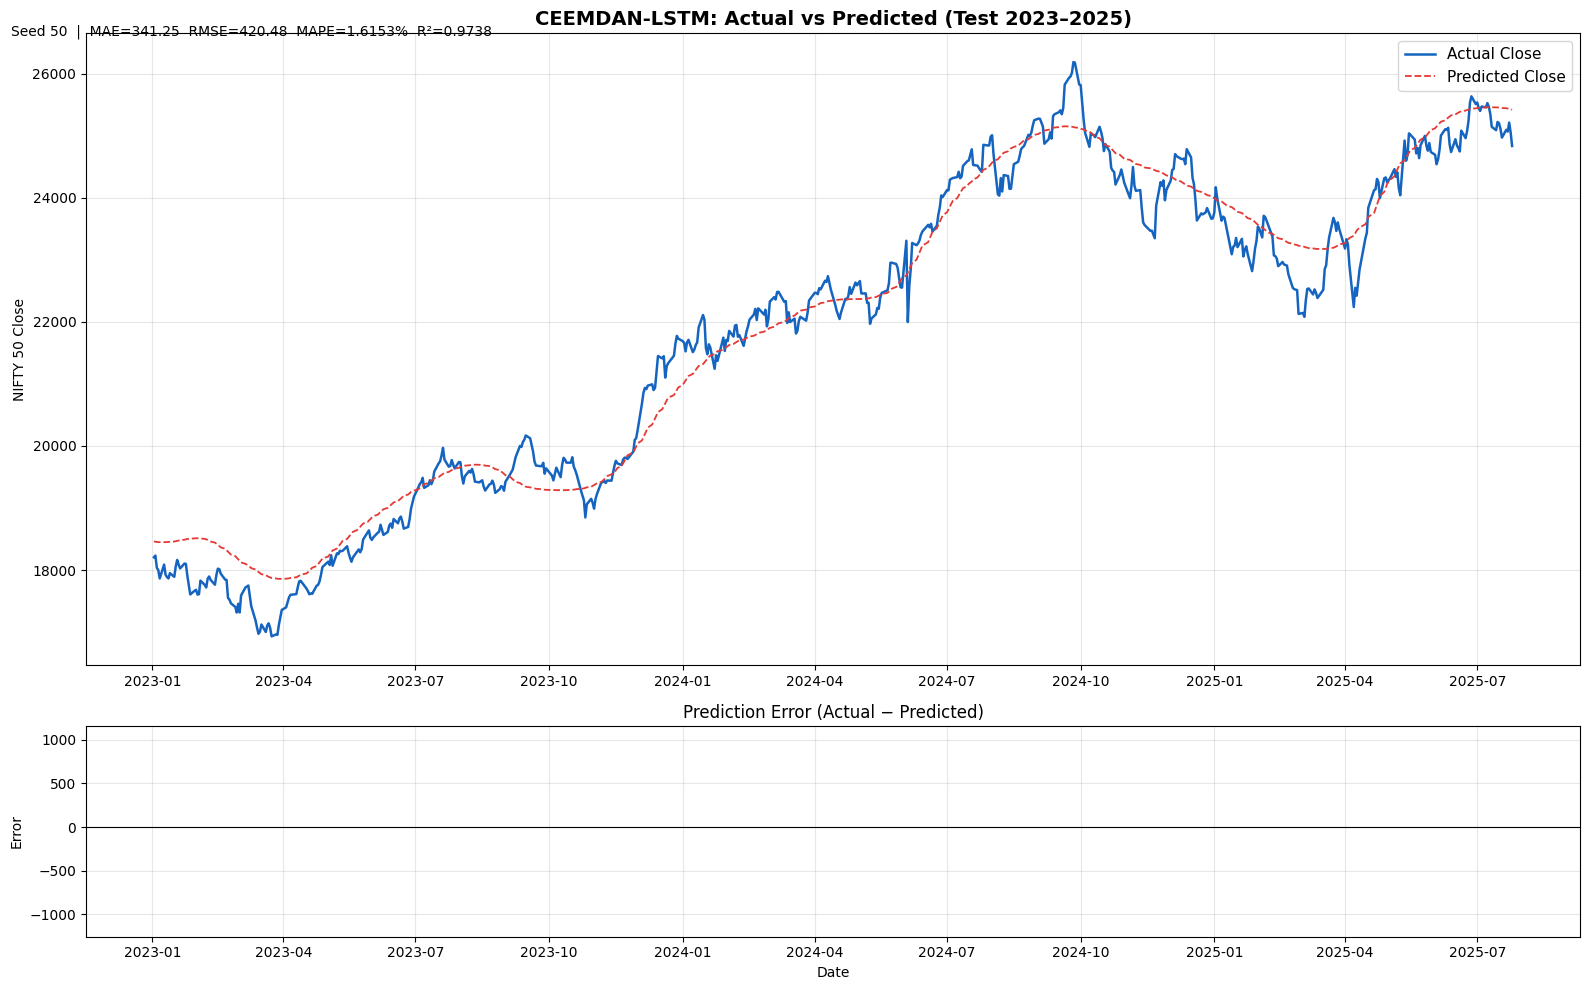

Plot saved → /content/actual_vs_predicted.png


In [15]:
# ============================================================
# Cell 16 — Plot: Actual vs Predicted (Test Set, seed=50)
# ============================================================
test_dates = df_test['Date'].values[:len(_last_y_true)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(test_dates, _last_y_true,
        color='#1565C0', lw=1.8, label='Actual Close')
ax.plot(test_dates, _last_y_hat,
        color='#E53935', lw=1.3, ls='--', label='Predicted Close')
ax.set_title('CEEMDAN-LSTM: Actual vs Predicted (Test 2023–2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('NIFTY 50 Close')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

ax2 = axes[1]
errs = _last_y_true - _last_y_hat
ax2.bar(test_dates, errs, color='#7B1FA2', alpha=0.6, width=1)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Prediction Error (Actual − Predicted)')
ax2.set_xlabel('Date'); ax2.set_ylabel('Error')
ax2.grid(True, alpha=0.3)

metrics_50 = compute_metrics(_last_y_true, _last_y_hat)
fig.text(0.01, 0.97,
         f'Seed 50  |  MAE={metrics_50["MAE"]:.2f}  '
         f'RMSE={metrics_50["RMSE"]:.2f}  '
         f'MAPE={metrics_50["MAPE"]:.4f}%  '
         f'R²={metrics_50["R2"]:.4f}',
         fontsize=10, va='top')

plt.tight_layout()
plt.savefig('/content/actual_vs_predicted.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Plot saved → /content/actual_vs_predicted.png')

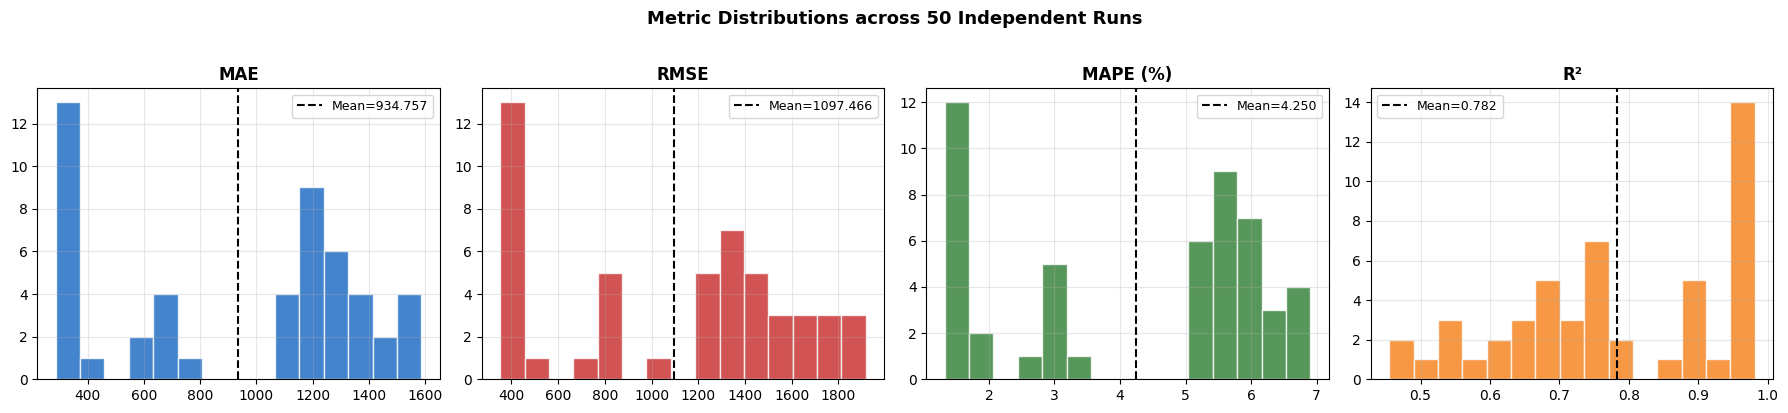

Plot saved → /content/metric_distributions.png


In [16]:
# ============================================================
# Cell 17 — Plot: Metric Distribution across 50 Runs
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
data_pairs = [
    ('MAE',  maes,  '#1565C0'),
    ('RMSE', rmses, '#C62828'),
    ('MAPE (%)', mapes, '#2E7D32'),
    ('R²',   r2s,   '#F57F17'),
]
for ax, (label, arr, col) in zip(axes, data_pairs):
    ax.hist(arr, bins=15, color=col, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(arr), color='black', ls='--', lw=1.5,
               label=f'Mean={np.mean(arr):.3f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Metric Distributions across 50 Independent Runs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/metric_distributions.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Plot saved → /content/metric_distributions.png')

In [17]:
# ============================================================
# Cell 18 — Volatility Regime Validation
# ============================================================
# Log-returns on full Close series
close_all = df[TARGET_COL].values.astype(np.float64)
log_ret   = np.log(close_all[1:] / close_all[:-1])

# 30-day rolling std, aligned to dates
rol_vol = (pd.Series(log_ret)
           .rolling(ROLLING_VOL_WINDOW).std())
vol_ser = pd.Series(rol_vol.values, index=df['Date'].values[1:])

# Align to test dates used
test_dates_used = df_test['Date'].values[:len(_last_y_true)]
vol_test  = vol_ser.reindex(test_dates_used, method='ffill')
vol_vals  = vol_test.values.astype(np.float64)
vol_med   = np.nanmedian(vol_vals)
vol_vals  = np.where(np.isnan(vol_vals), vol_med, vol_vals)

high_mask = vol_vals >= vol_med
low_mask  = ~high_mask

m_h = compute_metrics(_last_y_true[high_mask], _last_y_hat[high_mask])
m_l = compute_metrics(_last_y_true[low_mask],  _last_y_hat[low_mask])

print('\n' + '='*66)
print('  VOLATILITY REGIME VALIDATION')
print(f'  30-day rolling vol | Median = {vol_med:.6f}')
print('='*66)
print(f'  {"Metric":<12} {"High Volatility":>18} {"Low Volatility":>18}')
print('-'*66)
for k in ['MAE','RMSE','MAPE','R2']:
    print(f'  {k:<12} {m_h[k]:>18.4f} {m_l[k]:>18.4f}')
print('='*66)
print(f'  High-vol days : {high_mask.sum()}')
print(f'  Low-vol  days : {low_mask.sum()}')


  VOLATILITY REGIME VALIDATION
  30-day rolling vol | Median = 0.007017
  Metric          High Volatility     Low Volatility
------------------------------------------------------------------
  MAE                    353.6443           328.8161
  RMSE                   430.5342           410.1455
  MAPE                     1.6399             1.5906
  R2                       0.9691             0.9710
  High-vol days : 317
  Low-vol  days : 316


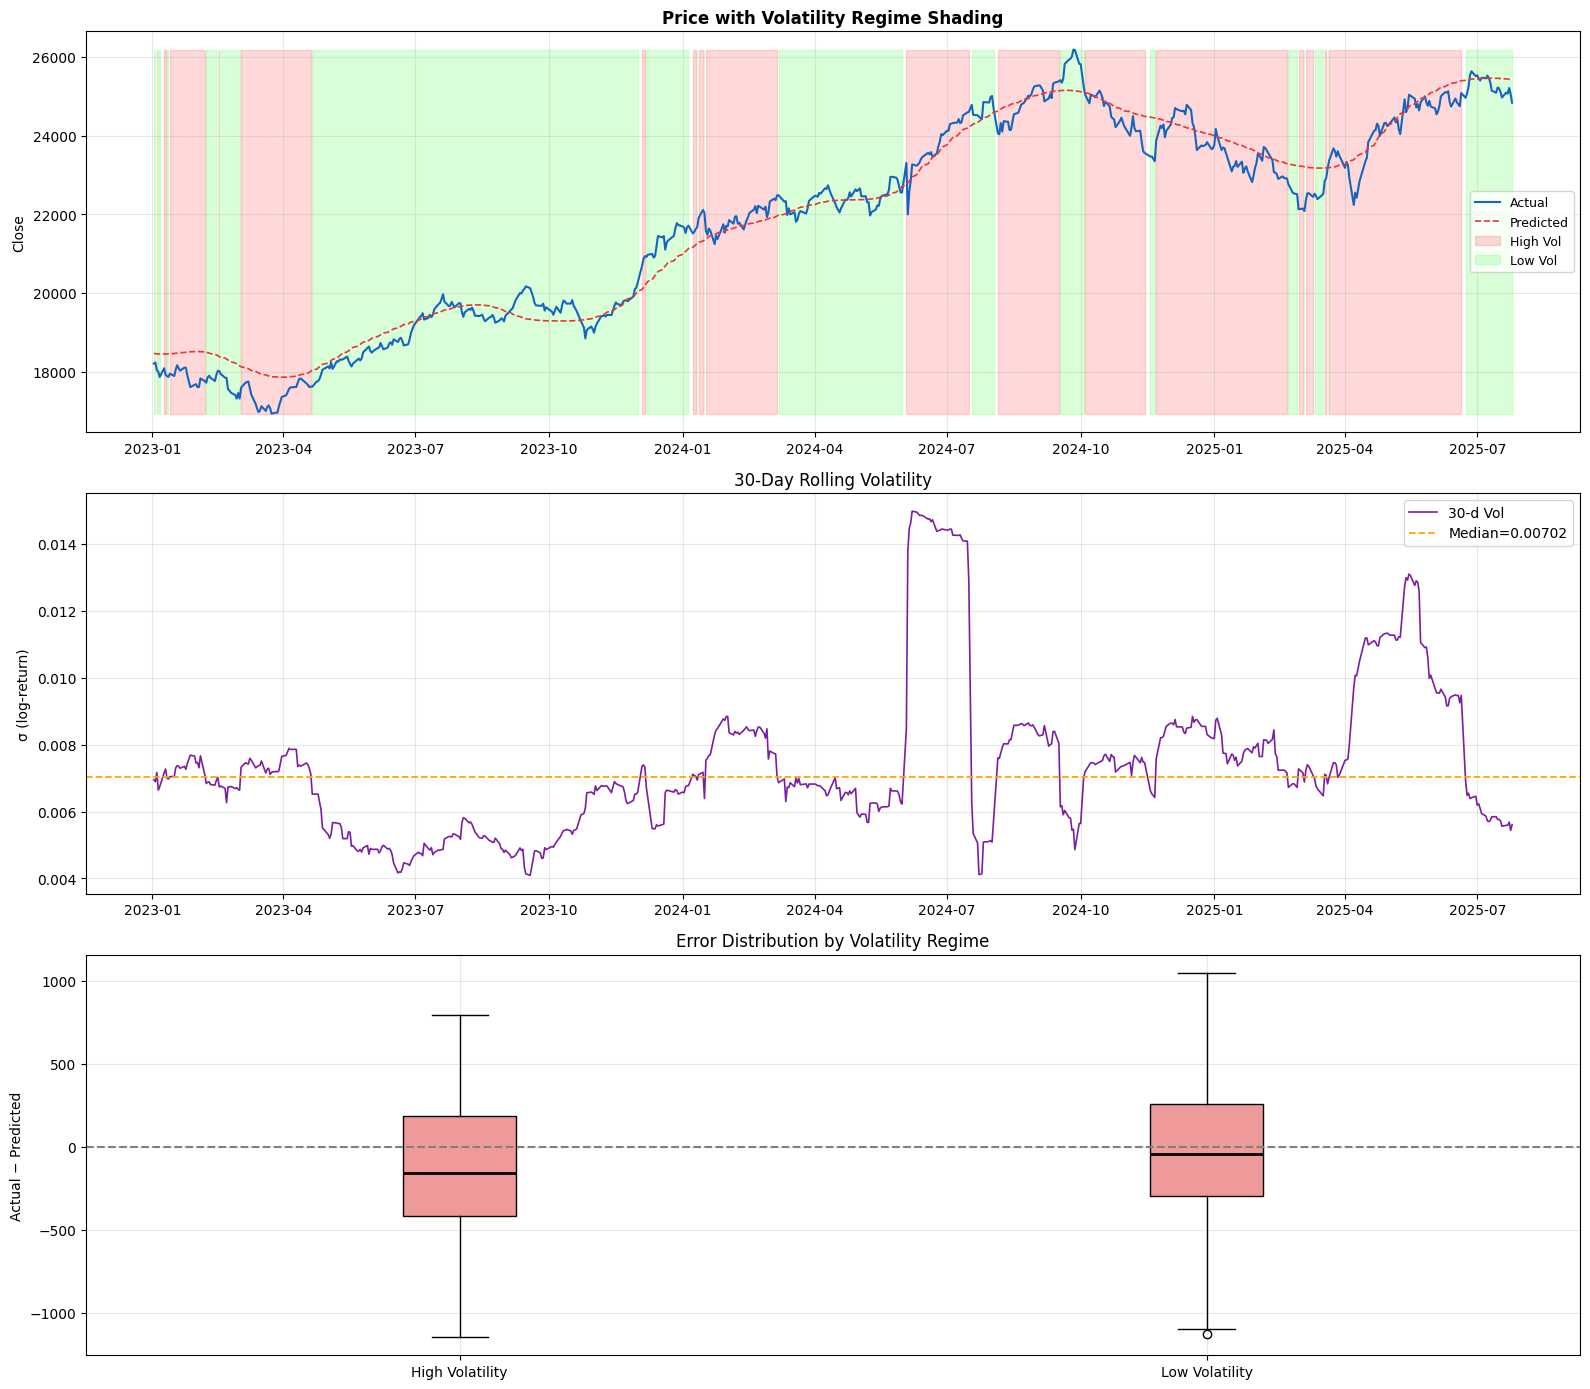

Plot saved → /content/volatility_regime.png


In [18]:
# ============================================================
# Cell 19 — Plot: Volatility Regime Segmentation
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Price with regime shading
ax1 = axes[0]
ax1.plot(test_dates_used, _last_y_true,
         '#1565C0', lw=1.5, label='Actual')
ax1.plot(test_dates_used, _last_y_hat,
         '#E53935', lw=1.2, ls='--', label='Predicted')
ax1.fill_between(test_dates_used,
    _last_y_true.min(), _last_y_true.max(),
    where=high_mask, alpha=0.15, color='red', label='High Vol')
ax1.fill_between(test_dates_used,
    _last_y_true.min(), _last_y_true.max(),
    where=low_mask,  alpha=0.15, color='lime', label='Low Vol')
ax1.set_title('Price with Volatility Regime Shading', fontweight='bold')
ax1.set_ylabel('Close'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Rolling volatility
ax2 = axes[1]
ax2.plot(test_dates_used, vol_vals, '#7B1FA2', lw=1.2, label='30-d Vol')
ax2.axhline(vol_med, color='orange', ls='--',
            lw=1.3, label=f'Median={vol_med:.5f}')
ax2.set_title('30-Day Rolling Volatility')
ax2.set_ylabel('σ (log-return)'); ax2.legend(); ax2.grid(True, alpha=0.3)

# Error box-plot
ax3 = axes[2]
ax3.boxplot(
    [_last_y_true[high_mask] - _last_y_hat[high_mask],
     _last_y_true[low_mask]  - _last_y_hat[low_mask]],
    labels=['High Volatility','Low Volatility'],
    patch_artist=True,
    boxprops=dict(facecolor='#EF9A9A'),
    medianprops=dict(color='black', linewidth=2))
ax3.axhline(0, color='grey', ls='--')
ax3.set_title('Error Distribution by Volatility Regime')
ax3.set_ylabel('Actual − Predicted'); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/volatility_regime.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → /content/volatility_regime.png')

In [21]:
# ============================================================
# Cell 20 — Multi-Step Recursive Forecasting
#           (5-day & 21-day ahead — NO retraining)
# ============================================================
def recursive_forecast_component(model, scaler, init_orig,
                                  n_steps, is_imf8=False,
                                  imf8_anchor=None):
    """
    Autoregressively predict n_steps starting from init_orig.
    For IMF8: init_orig is in first-difference space,
              anchor = last known raw IMF8 value.
    Returns original-scale predictions.
    """
    model.eval()
    win_sc = scaler.transform(
        init_orig.reshape(-1, 1)).flatten().astype(np.float32)
    win_sc = list(win_sc[-LOOK_BACK:])

    preds_sc = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(
                np.array(win_sc[-LOOK_BACK:], dtype=np.float32
                         )[np.newaxis, :, np.newaxis], device=DEVICE)
            p = model(x).item()
            preds_sc.append(p)
            win_sc.append(p)

    preds_orig = scaler.inverse_transform(
        np.array(preds_sc, dtype=np.float32).reshape(-1, 1)
    ).flatten().astype(np.float64)

    if is_imf8:
        preds_orig = float(imf8_anchor) + np.cumsum(preds_orig)

    return preds_orig


def multi_step_forecast(models, scalers, df_val, df_test, n_steps):
    """Recursive n-step forecast using last LOOK_BACK of val as seed."""
    y_hat_ms = np.zeros(n_steps, dtype=np.float64)

    # IMF8 uses difference-space scaler (ss8 not stored globally;
    # retrain imf8 scaler on val diffs for this purpose)
    tr_raw = df_train['IMF8'].values.astype(np.float64)
    vl_raw = df_val['IMF8'].values.astype(np.float64)
    d_tr   = np.diff(tr_raw)
    ss8    = StandardScaler(); ss8.fit(d_tr.reshape(-1,1))
    d_vl   = np.diff(np.concatenate([[tr_raw[-1]], vl_raw]))
    init_d = d_vl[-LOOK_BACK:]
    imf8_anchor = vl_raw[-1]

    for comp in ALL_COMPONENTS:
        if comp == 'IMF8':
            preds = recursive_forecast_component(
                models['IMF8'], ss8, init_d, n_steps,
                is_imf8=True, imf8_anchor=imf8_anchor)
        else:
            init = df_val[comp].values[-LOOK_BACK:].astype(np.float64)
            preds = recursive_forecast_component(
                models[comp], scalers[comp], init, n_steps)
        y_hat_ms += preds

    y_true_ms = df_test[TARGET_COL].values[:n_steps].astype(np.float64)
    return compute_metrics(y_true_ms, y_hat_ms), y_true_ms, y_hat_ms


# Run both horizons
print('\n' + '='*65)
print('  MULTI-STEP RECURSIVE FORECASTING  (no retraining)')
print('='*65)
print(f'  {"Horizon":<10} {"MAE":>10} {"RMSE":>10}'
      f' {"MAPE (%)":>10} {"R²":>10}')
print('-'*65)
ms_results = {}
for h in MULTISTEP_HORIZONS:
    res, yt, yp = multi_step_forecast(
        _last_models, _last_scalers, df_val, df_test, n_steps=h)
    ms_results[h] = (res, yt, yp)
    print(f'  {h}-day{"":5} {res["MAE"]:>10.2f} {res["RMSE"]:>10.2f} '
          f' {res["MAPE"]:>10.4f}  {res["R2"]:>10.4f}')
print('='*65)



  MULTI-STEP RECURSIVE FORECASTING  (no retraining)
  Horizon           MAE       RMSE   MAPE (%)         R²
-----------------------------------------------------------------
  5-day          386.82     409.40      2.1466     -7.9640
  21-day          613.01     664.15      3.4237    -14.7185


In [ ]:
# ============================================================
# Cell 22 — Download All Outputs
# ============================================================
from google.colab import files

for p in [OUTPUT_CSV, OUTPUT_TXT,
          '/content/actual_vs_predicted.png',
          '/content/metric_distributions.png',
          '/content/volatility_regime.png',
          '/content/training_time.png']:
    if os.path.exists(p):
        files.download(p)
        print(f'Downloaded: {p}')
    else:
        print(f'Not found  : {p}')